# X–Y Chromosome Correlation Analysis

Three focused analyses of how X and Y chromosome genetic diversity co-varies across the five 1000 Genomes super-populations.

| Section | Method | Question |
|---|---|---|
| 1 | Cross-metric correlation matrix | Which X metrics correlate with which Y metrics across populations? |
| 2 | Variant population-signature correlation | Do individual X and Y variants share the same population-frequency pattern? |
| 3 | Association rules | If a population has high Y diversity, does it also have high X diversity? |
| 4 | Intra- & inter-population SFS correlation | Is EAS_X more similar to EAS_Y than to AFR_Y? |

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import itertools
from scipy import stats
from scipy.stats import pearsonr, spearmanr, mannwhitneyu
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

DATA_DIR   = "/Users/aaditya/VS Code/1000 genome project/Code/"
OUT_DIR    = "/Users/aaditya/VS Code/1000 genome project/Output /"
POP_COLS   = ['AFR', 'AMR', 'EAS', 'EUR', 'SAS']
POP_COLORS = {'AFR': '#E74C3C', 'AMR': '#3498DB', 'EAS': '#2ECC71', 'EUR': '#F39C12', 'SAS': '#9B59B6'}

# ── Load pre-computed allele-frequency tables ────────────────────────────────
y_af   = pd.read_csv(DATA_DIR + 'chrY_AF_by_population.csv')
x_af   = pd.read_csv(DATA_DIR + 'chrX_AF_by_population.csv')
y_vars = pd.read_csv(DATA_DIR + 'chrY_variant_summary_qc.csv')
x_vars = pd.read_csv(DATA_DIR + 'chrX_variant_summary_qc.csv')
for df in [y_af, x_af]:
    for c in POP_COLS:
        df[c] = pd.to_numeric(df[c], errors='coerce')

# ── Diversity metrics ────────────────────────────────────────────────────────
def diversity_metrics(af_df):
    results = {}
    for pop in POP_COLS:
        af    = af_df[pop].dropna().values
        het   = 2 * af * (1 - af)
        other = [c for c in POP_COLS if c != pop]
        private = int(((af_df[pop] > 0.01) & (af_df[other].max(axis=1) < 0.01)).sum())
        results[pop] = {
            'avg_heterozygosity': float(np.nanmean(het)),
            'private_variants'  : private,
            'n_polymorphic'     : int(np.sum(af > 0.01)),
            'mean_af'           : float(np.nanmean(af)),
        }
    return pd.DataFrame(results).T

y_div = diversity_metrics(y_af)
x_div = diversity_metrics(x_af)

# ── Tajima's D ───────────────────────────────────────────────────────────────
# Per-population sample sizes (haploid Y counts; diploid-equivalent X counts)
Y_POP_N = {'AFR': 319, 'AMR': 170, 'EAS': 244, 'EUR': 240, 'SAS': 260}
X_POP_N = {'AFR': 661, 'AMR': 347, 'EAS': 504, 'EUR': 503, 'SAS': 489}

def tajimas_d(af_series, n_samples=250):
    af = af_series.dropna().values
    af = af[(af > 0) & (af < 1)]
    if len(af) < 2 or n_samples <= 2:
        return np.nan
    S  = len(af)
    pi = float(np.sum(2 * af * (1 - af)))
    a1 = sum(1.0 / i for i in range(1, n_samples))
    a2 = sum(1.0 / (i ** 2) for i in range(1, n_samples))
    if a1 == 0:
        return np.nan
    b1 = (n_samples + 1) / (3 * (n_samples - 1))
    b2 = (2 * (n_samples ** 2 + n_samples + 3)) / (9 * n_samples * (n_samples - 1))
    c1 = b1 - (1 / a1)
    c2 = b2 - ((n_samples + 2) / (a1 * n_samples)) + (a2 / (a1 ** 2))
    e1 = c1 / a1
    e2 = c2 / (a1 ** 2 + a2)
    theta_w = S / a1
    var_d   = e1 * S + e2 * S * (S - 1)
    return (pi - theta_w) / np.sqrt(var_d) if var_d > 0 else np.nan

y_td = {pop: tajimas_d(y_af[pop], Y_POP_N[pop]) for pop in POP_COLS}
x_td = {pop: tajimas_d(x_af[pop], X_POP_N[pop]) for pop in POP_COLS}
td_df = pd.DataFrame({'Y_tajD': y_td, 'X_tajD': x_td})

# ── Pairwise FST ─────────────────────────────────────────────────────────────
def pairwise_fst(af_df):
    n   = len(POP_COLS)
    fst = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            p1   = af_df[POP_COLS[i]].values
            p2   = af_df[POP_COLS[j]].values
            mask = ~(np.isnan(p1) | np.isnan(p2))
            p1m, p2m = p1[mask], p2[mask]
            pt   = (p1m + p2m) / 2
            ht   = 2 * pt * (1 - pt)
            hs   = (2*p1m*(1-p1m) + 2*p2m*(1-p2m)) / 2
            denom = ht.mean()
            fst[i, j] = max(0.0, (ht - hs).mean() / denom) if denom > 0 else 0.0
    return pd.DataFrame(fst, index=POP_COLS, columns=POP_COLS)

y_fst = pairwise_fst(y_af)
x_fst = pairwise_fst(x_af)

# ── Derived FST values used across sections ───────────────────────────────────
pairs          = [(POP_COLS[i], POP_COLS[j]) for i in range(5) for j in range(i+1, 5)]
pair_labels    = [f'{a}-{b}' for a, b in pairs]
y_fst_vals     = [y_fst.loc[a, b] for a, b in pairs]
x_fst_vals     = [x_fst.loc[a, b] for a, b in pairs]
y_mfst_arr     = np.array([y_fst.loc[p, [c for c in POP_COLS if c != p]].mean() for p in POP_COLS])
x_mfst_arr     = np.array([x_fst.loc[p, [c for c in POP_COLS if c != p]].mean() for p in POP_COLS])
scatter_colors = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6',
                  '#1ABC9C','#E67E22','#8E44AD','#2980B9','#D35400']
m, b = np.polyfit(y_fst_vals, x_fst_vals, 1)

print('Setup complete.')
print(f'  Y: {len(y_vars):,} variants  |  X: {len(x_vars):,} variants')
print(f'  Tajima D range  Y: [{td_df.Y_tajD.min():.4f}, {td_df.Y_tajD.max():.4f}]')
print(f'  FST range       Y: [{y_fst.values[y_fst.values>0].min():.4f}, {y_fst.values.max():.4f}]')

## Section 1 — Cross-Metric Correlation Matrix

Build a unified table with **5 rows (populations)** and **10 columns** (all computed metrics for both chromosomes),
then compute the full Pearson correlation matrix across populations.
This answers: *"Do metrics that are high in one population on Y also tend to be high on X?"*

| Label | Meaning |
|---|---|
| Y_het / X_het | Average heterozygosity per population |
| Y_priv / X_priv | Private variant count (unique to that population) |
| Y_poly / X_poly | Number of polymorphic sites (AF > 1%) |
| Y_tajD / X_tajD | Tajima's D (selection signal) |
| Y_mFST / X_mFST | Mean pairwise FST (population isolation) |

Cross-metric table (5 populations × 10 metrics):
       Y_het    X_het  Y_priv    X_priv  Y_poly    X_poly   Y_tajD   X_tajD   Y_mFST   X_mFST
AFR  0.00863  0.03725  1993.0  287209.0  4060.0  654892.0 -0.21711 -0.09012  0.31939  0.10031
AMR  0.01149  0.02605  1981.0   17143.0  5333.0  424389.0 -0.16376 -0.07617  0.12670  0.04255
EAS  0.01046  0.02128  4080.0   42651.0  5259.0  301958.0 -0.18588 -0.08231  0.18796  0.06861
EUR  0.00947  0.02343   620.0   27341.0  4224.0  333450.0 -0.17069 -0.06515  0.15132  0.05831
SAS  0.01252  0.02455  3265.0   50805.0  5278.0  356783.0 -0.18761 -0.07968  0.13390  0.04602

Cross-chromosome correlations (X metric vs Y metric):
Pair                        r        p   sig
---------------------------------------------
Y_het vs X_het          -0.547   0.3405    ns
Y_het vs X_priv         -0.644   0.2409    ns
Y_het vs X_poly         -0.534   0.3536    ns
Y_het vs X_tajD          0.144   0.8176    ns
Y_het vs X_mFST         -0.833   0.0799     *
Y_priv vs X

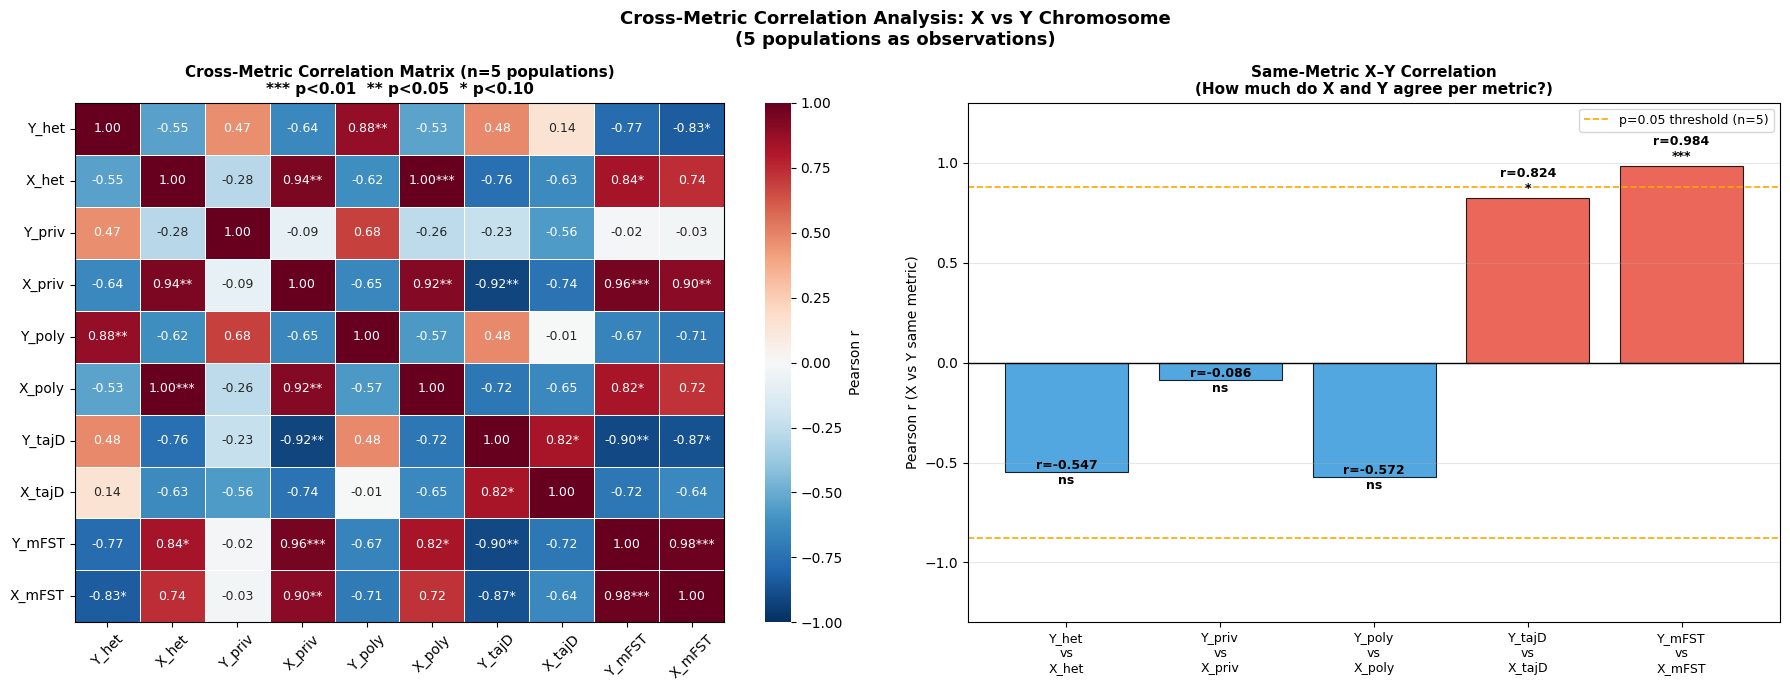

In [2]:
from scipy.stats import pearsonr
import itertools

# ── Build 5-population metric table ─────────────────────────────────────────
y_mfst_arr = np.array([y_fst.loc[p, [c for c in POP_COLS if c != p]].mean() for p in POP_COLS])
x_mfst_arr = np.array([x_fst.loc[p, [c for c in POP_COLS if c != p]].mean() for p in POP_COLS])

metric_df = pd.DataFrame({
    'Y_het'  : y_div['avg_heterozygosity'].astype(float).values,
    'X_het'  : x_div['avg_heterozygosity'].astype(float).values,
    'Y_priv' : y_div['private_variants'].astype(float).values,
    'X_priv' : x_div['private_variants'].astype(float).values,
    'Y_poly' : y_div['n_polymorphic'].astype(float).values,
    'X_poly' : x_div['n_polymorphic'].astype(float).values,
    'Y_tajD' : td_df['Y_tajD'].values,
    'X_tajD' : td_df['X_tajD'].values,
    'Y_mFST' : y_mfst_arr,
    'X_mFST' : x_mfst_arr,
}, index=POP_COLS)

print('Cross-metric table (5 populations × 10 metrics):')
print(metric_df.round(5).to_string())

# ── Full 10×10 Pearson correlation matrix ───────────────────────────────────
corr_matrix = metric_df.corr(method='pearson')

# ── p-value matrix (n=5 → t-test) ───────────────────────────────────────────
cols = metric_df.columns.tolist()
pval_matrix = pd.DataFrame(np.ones((10, 10)), index=cols, columns=cols)
for c1, c2 in itertools.combinations(cols, 2):
    r, p = pearsonr(metric_df[c1], metric_df[c2])
    pval_matrix.loc[c1, c2] = p
    pval_matrix.loc[c2, c1] = p

# ── Figure: annotated heatmap with significance stars ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Build annotation matrix: show r value + significance stars
annot = pd.DataFrame('', index=cols, columns=cols)
for c1 in cols:
    for c2 in cols:
        if c1 == c2:
            annot.loc[c1, c2] = '1.00'
            continue
        r_val = corr_matrix.loc[c1, c2]
        p_val_cell = pval_matrix.loc[c1, c2]
        stars = '***' if p_val_cell < 0.01 else ('**' if p_val_cell < 0.05 else ('*' if p_val_cell < 0.10 else ''))
        annot.loc[c1, c2] = f'{r_val:.2f}{stars}'

mask = np.zeros((10, 10), dtype=bool)  # show all
sns.heatmap(corr_matrix.astype(float), annot=annot, fmt='', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=axes[0], linewidths=0.5,
            annot_kws={'size': 9}, cbar_kws={'label': 'Pearson r'})
axes[0].set_title('Cross-Metric Correlation Matrix (n=5 populations)\n'
                  '*** p<0.01  ** p<0.05  * p<0.10',
                  fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

# Block structure: highlight X-vs-X, Y-vs-Y, X-vs-Y blocks
for spine in axes[0].spines.values():
    spine.set_visible(True)

# Rectangle overlays for block structure
from matplotlib.patches import Rectangle
# Y-Y block (rows/cols 0,2,4,6,8 → indices 0,2,4,6,8 but in order Y_het,Y_priv,Y_poly,Y_tajD,Y_mFST = 0,2,4,6,8)
y_idx = [i for i, c in enumerate(cols) if c.startswith('Y')]
x_idx = [i for i, c in enumerate(cols) if c.startswith('X')]

# Print cross-chromosome block stats
print('\nCross-chromosome correlations (X metric vs Y metric):')
print(f'{"Pair":<20} {"r":>8} {"p":>8} {"sig":>5}')
print('-' * 45)
cross_pairs = []
for yi in y_idx:
    for xi in x_idx:
        yc, xc = cols[yi], cols[xi]
        r_val = corr_matrix.loc[yc, xc]
        p_val_cell = pval_matrix.loc[yc, xc]
        sig = '***' if p_val_cell < 0.01 else ('**' if p_val_cell < 0.05 else ('*' if p_val_cell < 0.10 else 'ns'))
        cross_pairs.append({'Y_metric': yc, 'X_metric': xc, 'r': r_val, 'p': p_val_cell, 'sig': sig})
        print(f'{yc} vs {xc:<12} {r_val:>8.3f} {p_val_cell:>8.4f} {sig:>5}')

# Bar chart of cross-chromosome correlations
cross_df = pd.DataFrame(cross_pairs)
cross_df['label'] = cross_df['Y_metric'].str.replace('Y_','') + '\n(Y vs X)'
# For same-metric pairs only
same_metric = cross_df[cross_df['Y_metric'].str.replace('Y_','') == cross_df['X_metric'].str.replace('X_','')]

bar_colors = ['#E74C3C' if r >= 0 else '#3498DB' for r in same_metric['r']]
bars = axes[1].bar(range(len(same_metric)), same_metric['r'].values,
                   color=bar_colors, alpha=0.85, edgecolor='black', linewidth=0.8)
axes[1].set_xticks(range(len(same_metric)))
axes[1].set_xticklabels([
    f"{row.Y_metric}\nvs\n{row.X_metric}" for _, row in same_metric.iterrows()
], fontsize=9)
axes[1].axhline(0, color='black', linewidth=1)
axes[1].axhline(0.878, color='orange', linewidth=1.2, linestyle='--', label='p=0.05 threshold (n=5)')
axes[1].axhline(-0.878, color='orange', linewidth=1.2, linestyle='--')
for i, (bar, row) in enumerate(zip(bars, same_metric.itertuples())):
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 h + 0.03 if h >= 0 else h - 0.06,
                 f'r={h:.3f}\n{row.sig}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_ylim(-1.3, 1.3)
axes[1].set_ylabel('Pearson r (X vs Y same metric)')
axes[1].set_title('Same-Metric X–Y Correlation\n(How much do X and Y agree per metric?)', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Cross-Metric Correlation Analysis: X vs Y Chromosome\n(5 populations as observations)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/Users/aaditya/VS Code/1000 genome project/Output /coevo_09_corr_matrix.png",
            dpi=150, bbox_inches='tight')
plt.show()

## Section 2 — Variant Population-Signature Correlation

Each variant has a **population signature** — a 5-dimensional vector `[AF_AFR, AF_AMR, AF_EAS, AF_EUR, AF_SAS]`.
Two variants with the same signature respond identically to population history.

**Method:**
1. Randomly sample 5,000 Y variants and 5,000 X variants
2. Compute a **5,000 × 5,000 correlation matrix** between Y and X population signatures
3. Cluster the signature archetypes to find shared evolutionary patterns
4. Plot the distribution of maximum X–Y correlations per Y variant

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
N_SAMPLE = 5000

# ── Sample and clean ────────────────────────────────────────────────────────
y_sample_idx = np.random.choice(len(y_af), size=min(N_SAMPLE, len(y_af)), replace=False)
x_sample_idx = np.random.choice(len(x_af), size=min(N_SAMPLE, len(x_af)), replace=False)

Y_mat = y_af.iloc[y_sample_idx][POP_COLS].values.astype(float)  # (5000, 5)
X_mat = x_af.iloc[x_sample_idx][POP_COLS].values.astype(float)  # (5000, 5)

# Drop rows with any NaN
y_ok = ~np.isnan(Y_mat).any(axis=1)
x_ok = ~np.isnan(X_mat).any(axis=1)
Y_mat = Y_mat[y_ok]
X_mat = X_mat[x_ok]
print(f"Y variants for signature analysis: {len(Y_mat):,}")
print(f"X variants for signature analysis: {len(X_mat):,}")

# ── Normalize each variant's AF vector (z-score across 5 pops) ──────────────
def norm_rows(M):
    mu  = M.mean(axis=1, keepdims=True)
    sig = M.std(axis=1, keepdims=True) + 1e-9
    return (M - mu) / sig

Y_norm = norm_rows(Y_mat)   # (n_y, 5)
X_norm = norm_rows(X_mat)   # (n_x, 5)

# ── Correlation matrix Y_norm @ X_norm.T / (n_pops-1) ───────────────────────
# Each element [i,j] = Pearson r between Y variant i and X variant j
corr_yx = (Y_norm @ X_norm.T) / len(POP_COLS)          # shape (n_y, n_x)
print(f"Correlation matrix shape: {corr_yx.shape}")
print(f"Correlation range: [{corr_yx.min():.3f}, {corr_yx.max():.3f}]")

# ── For each Y variant, find its best-matching X variant ────────────────────
best_corr_per_y = corr_yx.max(axis=1)          # max X correlation for each Y variant
best_match_idx  = corr_yx.argmax(axis=1)        # index of best X match
mean_corr_per_y = corr_yx.mean(axis=1)          # mean correlation with all X variants

print(f"\nY variants with best X correlation > 0.9: {(best_corr_per_y > 0.9).sum():,}")
print(f"Y variants with best X correlation > 0.8: {(best_corr_per_y > 0.8).sum():,}")
print(f"Mean best-match correlation: {best_corr_per_y.mean():.3f}")
print(f"Mean average correlation:    {mean_corr_per_y.mean():.3f}")

# ── K-Means on population signature archetypes ───────────────────────────────
combined = np.vstack([Y_norm, X_norm])          # (n_y + n_x, 5)
labels_all = np.array(['Y']*len(Y_norm) + ['X']*len(X_norm))

k = 6
km = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = km.fit_predict(combined)

y_clusters = clusters[:len(Y_norm)]
x_clusters = clusters[len(Y_norm):]

# How variants split across clusters
cluster_df = pd.DataFrame({
    'cluster': np.concatenate([y_clusters, x_clusters]),
    'chrom'  : np.array(['Y']*len(Y_norm) + ['X']*len(X_norm))
})
split = cluster_df.groupby(['cluster','chrom']).size().unstack(fill_value=0)
split['Y_frac'] = split.get('Y', 0) / (split.get('Y', 0) + split.get('X', 0))
split['X_frac'] = split.get('X', 0) / (split.get('Y', 0) + split.get('X', 0))
print('\nCluster composition (Y vs X fraction):')
print(split.round(3))

# ── Figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# (0,0) Distribution of best-match correlations
axes[0,0].hist(best_corr_per_y, bins=60, color='#9B59B6', alpha=0.8, edgecolor='white', linewidth=0.3)
axes[0,0].axvline(best_corr_per_y.mean(), color='red', linewidth=2,
                  label=f'Mean = {best_corr_per_y.mean():.3f}')
axes[0,0].axvline(0.8, color='orange', linewidth=1.5, linestyle='--', label='r=0.80 threshold')
axes[0,0].set_xlabel('Max Pearson r (best X match per Y variant)')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Distribution of Best X–Y\nVariant Signature Correlations', fontsize=11, fontweight='bold')
axes[0,0].legend(fontsize=9)
axes[0,0].grid(alpha=0.3)

# (0,1) Mean correlation per Y variant
axes[0,1].hist(mean_corr_per_y, bins=60, color='#1ABC9C', alpha=0.8, edgecolor='white', linewidth=0.3)
axes[0,1].axvline(mean_corr_per_y.mean(), color='red', linewidth=2,
                  label=f'Mean = {mean_corr_per_y.mean():.3f}')
axes[0,1].set_xlabel('Mean Pearson r (all X variants per Y variant)')
axes[0,1].set_ylabel('Count')
axes[0,1].set_title('Distribution of Mean X–Y\nVariant Correlations', fontsize=11, fontweight='bold')
axes[0,1].legend(fontsize=9)
axes[0,1].grid(alpha=0.3)

# (0,2) Cluster centroid population profiles
centroid_df = pd.DataFrame(km.cluster_centers_, columns=POP_COLS)
colors_k = plt.cm.Set1(np.linspace(0, 0.8, k))
for ci in range(k):
    axes[0,2].plot(POP_COLS, centroid_df.iloc[ci], 'o-', color=colors_k[ci],
                   linewidth=2, markersize=7, label=f'Cluster {ci}')
axes[0,2].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[0,2].set_ylabel('Normalized AF (z-score)')
axes[0,2].set_title(f'K-Means Cluster Centroids (k={k})\nPopulation Signature Archetypes', fontsize=11, fontweight='bold')
axes[0,2].legend(fontsize=8, ncol=2)
axes[0,2].grid(alpha=0.3)

# (1,0) Cluster composition bar chart
x_pos_bar = np.arange(k)
w_bar = 0.35
axes[1,0].bar(x_pos_bar - w_bar/2, split.get('Y', pd.Series([0]*k)).values, w_bar,
              label='Y variants', color='#3498DB', alpha=0.85, edgecolor='black', linewidth=0.5)
axes[1,0].bar(x_pos_bar + w_bar/2, split.get('X', pd.Series([0]*k)).values, w_bar,
              label='X variants', color='#E74C3C', alpha=0.85, edgecolor='black', linewidth=0.5)
axes[1,0].set_xticks(x_pos_bar)
axes[1,0].set_xticklabels([f'Cluster {i}' for i in range(k)])
axes[1,0].set_ylabel('Number of variants')
axes[1,0].set_title('X vs Y Variant Membership per Cluster', fontsize=11, fontweight='bold')
axes[1,0].legend(fontsize=9)
axes[1,0].grid(axis='y', alpha=0.3)

# (1,1) Fraction heatmap
frac_data = pd.DataFrame({
    'Y fraction': split.get('Y', pd.Series([0]*k)).values / (split.get('Y', pd.Series([0]*k)).values + split.get('X', pd.Series([0]*k)).values + 1e-9),
    'X fraction': split.get('X', pd.Series([0]*k)).values / (split.get('Y', pd.Series([0]*k)).values + split.get('X', pd.Series([0]*k)).values + 1e-9),
}, index=[f'C{i}' for i in range(k)])
sns.heatmap(frac_data.T, annot=True, fmt='.2f', cmap='RdBu_r', vmin=0, vmax=1,
            ax=axes[1,1], linewidths=0.5, cbar_kws={'label': 'Fraction'})
axes[1,1].set_title('Fraction of X vs Y\nVariants per Cluster', fontsize=11, fontweight='bold')

# (1,2) Best-match scatter: Y_AF_AFR vs best-match X_AF_AFR
sample_n = min(2000, len(Y_mat))
idx_plot  = np.random.choice(len(Y_mat), size=sample_n, replace=False)
y_afr_plot = Y_mat[idx_plot, POP_COLS.index('AFR')]
x_afr_plot = X_mat[best_match_idx[idx_plot], POP_COLS.index('AFR')]
r_afr, p_afr = pearsonr(y_afr_plot, x_afr_plot)
axes[1,2].scatter(y_afr_plot, x_afr_plot, s=3, alpha=0.3, color='#8E44AD')
axes[1,2].set_xlabel('Y variant AFR allele freq')
axes[1,2].set_ylabel('Best-match X variant AFR allele freq')
axes[1,2].set_title(f'Y vs Best-Match X: AFR Frequency\n(r={r_afr:.3f}, p={p_afr:.4f})',
                    fontsize=11, fontweight='bold')
axes[1,2].grid(alpha=0.3)

plt.suptitle('Variant Population-Signature Correlation: X vs Y Chromosome',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/Users/aaditya/VS Code/1000 genome project/Output /coevo_10_sig_corr.png",
            dpi=150, bbox_inches='tight')
plt.show()

## Section 3 — Association Rules

Treat each **population** as a transaction and each metric as an item (TRUE if above median).
Mine rules of the form: **{Y_het is high} → {X_tajD is negative}** with confidence and lift.

- **Support**: fraction of populations where both antecedent and consequent are TRUE
- **Confidence**: P(consequent | antecedent) — how reliably the rule holds
- **Lift**: confidence / P(consequent alone) — >1 = associated, <1 = inverse, 1.0 = independent

Binary transaction matrix (1=above median):
     Y_het  X_het  Y_priv  X_priv  Y_poly  X_poly  Y_tajD  X_tajD  Y_mFST  X_mFST  Y_tajD_neg  X_tajD_neg
AFR      0      1       0       1       0       1       0       0       1       1           1           1
AMR      1      1       0       0       1       1       1       1       0       0           0           0
EAS      0      0       1       0       0       0       0       0       1       1           0           1
EUR      0      0       0       0       0       0       1       1       0       0           0           0
SAS      1      0       1       1       1       0       0       0       0       0           1           0

Total cross-chromosome rules mined: 72
Strong rules (conf ≥ 0.6, lift ≥ 1.2): 8

Top 20 cross-chromosome association rules:
antecedent consequent  support  confidence  lift
    Y_mFST     X_mFST      0.4         1.0   2.5
    Y_mFST X_tajD_neg      0.4         1.0   2.5
    Y_tajD     X_tajD      0.4         1.0   2.5

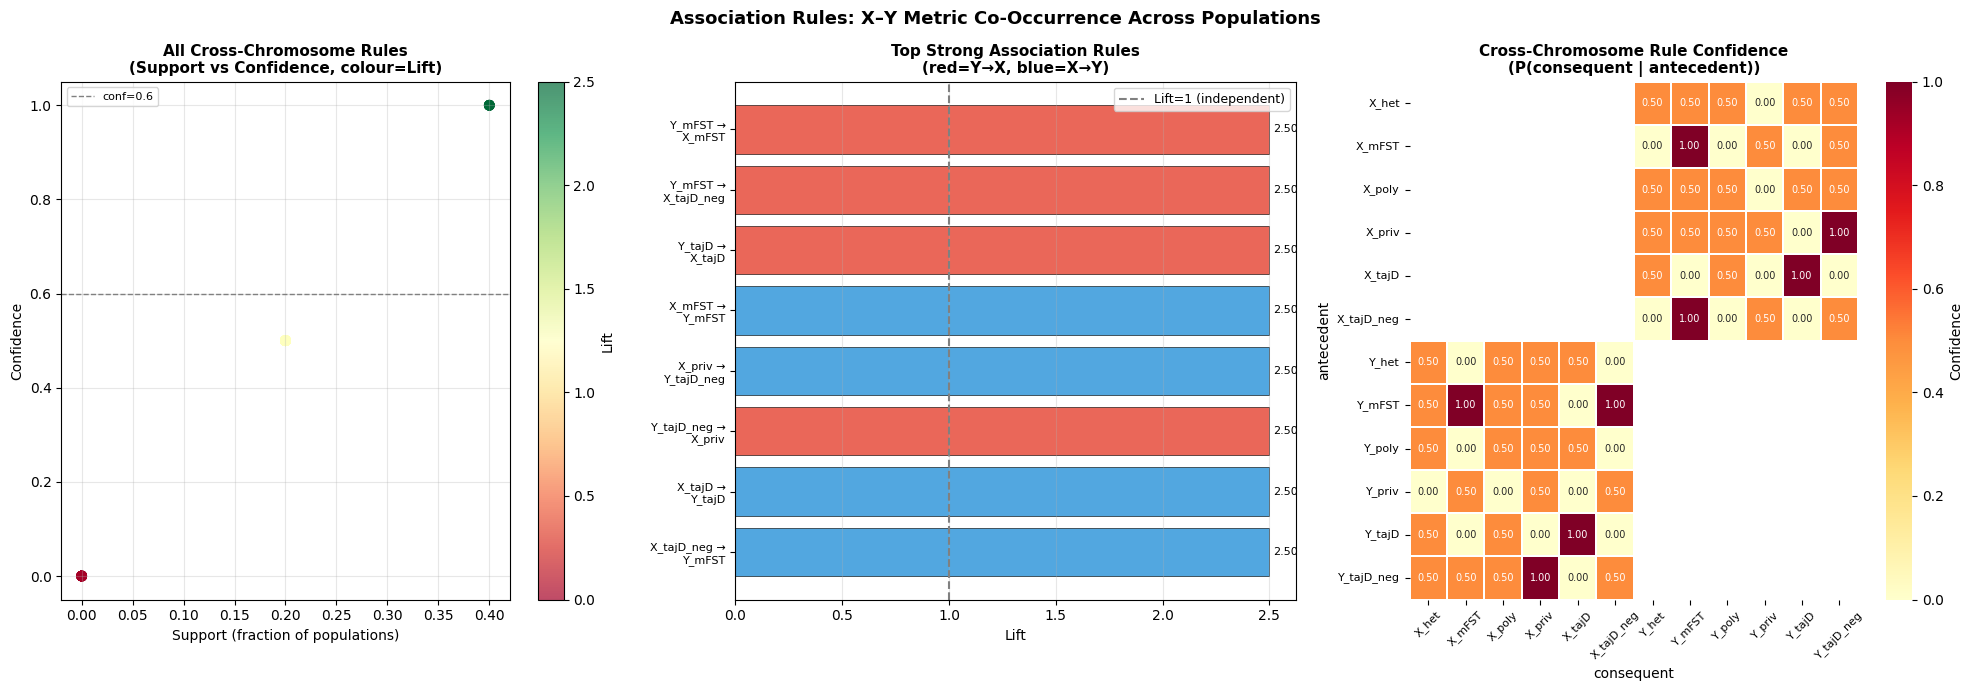


Top rules in plain English:
  IF Y_mFST is HIGH  →  X_mFST is HIGH
     support=0.40  confidence=1.00  lift=2.50
  IF Y_mFST is HIGH  →  X_tajD_neg is HIGH
     support=0.40  confidence=1.00  lift=2.50
  IF Y_tajD is HIGH  →  X_tajD is HIGH
     support=0.40  confidence=1.00  lift=2.50
  IF X_mFST is HIGH  →  Y_mFST is HIGH
     support=0.40  confidence=1.00  lift=2.50
  IF X_priv is HIGH  →  Y_tajD_neg is HIGH
     support=0.40  confidence=1.00  lift=2.50
  IF Y_tajD_neg is HIGH  →  X_priv is HIGH
     support=0.40  confidence=1.00  lift=2.50
  IF X_tajD is HIGH  →  Y_tajD is HIGH
     support=0.40  confidence=1.00  lift=2.50
  IF X_tajD_neg is HIGH  →  Y_mFST is HIGH
     support=0.40  confidence=1.00  lift=2.50


In [4]:
# ── Build binary transaction matrix ─────────────────────────────────────────
# Each column = metric; True = population is above the median for that metric
binary_df = (metric_df > metric_df.median()).astype(int)

# Also add "high magnitude Tajima's D" (more negative = higher selection pressure)
binary_df['Y_tajD_neg'] = (metric_df['Y_tajD'] < metric_df['Y_tajD'].median()).astype(int)
binary_df['X_tajD_neg'] = (metric_df['X_tajD'] < metric_df['X_tajD'].median()).astype(int)

print('Binary transaction matrix (1=above median):')
print(binary_df.to_string())

# ── Mine all 2-item rules (antecedent → consequent) ─────────────────────────
items = binary_df.columns.tolist()
n_pops = len(binary_df)

rules = []
for ant in items:
    for con in items:
        if ant == con:
            continue
        ant_vec = binary_df[ant].values
        con_vec = binary_df[con].values
        support    = float((ant_vec & con_vec).sum()) / n_pops
        ant_supp   = float(ant_vec.sum()) / n_pops
        con_supp   = float(con_vec.sum()) / n_pops
        if ant_supp == 0:
            continue
        confidence = support / ant_supp
        lift       = confidence / con_supp if con_supp > 0 else np.nan
        rules.append({
            'antecedent' : ant,
            'consequent' : con,
            'support'    : support,
            'confidence' : confidence,
            'lift'       : lift,
        })

rules_df = pd.DataFrame(rules).sort_values('lift', ascending=False)

# ── Filter: cross-chromosome rules only (Y metric → X metric or vice versa) ─
cross_rules = rules_df[
    ((rules_df['antecedent'].str.startswith('Y')) & (rules_df['consequent'].str.startswith('X'))) |
    ((rules_df['antecedent'].str.startswith('X')) & (rules_df['consequent'].str.startswith('Y')))
].copy()

# Keep rules with confidence >= 0.6 and lift >= 1.2
strong_rules = cross_rules[(cross_rules['confidence'] >= 0.6) & (cross_rules['lift'] >= 1.2)]
strong_rules = strong_rules.drop_duplicates(subset=['antecedent','consequent'])

print(f'\nTotal cross-chromosome rules mined: {len(cross_rules)}')
print(f'Strong rules (conf ≥ 0.6, lift ≥ 1.2): {len(strong_rules)}')
print('\nTop 20 cross-chromosome association rules:')
print(strong_rules.head(20)[['antecedent','consequent','support','confidence','lift']].to_string(index=False))

# ── Figure: Association rule scatter + top-rule heatmap ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# (0) Support vs Confidence scatter (all cross rules), coloured by lift
sc = axes[0].scatter(cross_rules['support'], cross_rules['confidence'],
                     c=cross_rules['lift'].clip(0, 3), cmap='RdYlGn',
                     s=60, alpha=0.7, edgecolors='none')
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].axhline(0.6, color='gray', linewidth=1, linestyle='--', label='conf=0.6')
axes[0].set_xlabel('Support (fraction of populations)'); axes[0].set_ylabel('Confidence')
axes[0].set_title('All Cross-Chromosome Rules\n(Support vs Confidence, colour=Lift)',
                  fontsize=11, fontweight='bold')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# (1) Lift bar chart for strong rules
if len(strong_rules) > 0:
    plot_rules = strong_rules.head(15).copy()
    plot_rules['rule_label'] = plot_rules['antecedent'] + ' →\n' + plot_rules['consequent']
    bar_cols = ['#E74C3C' if r['antecedent'].startswith('Y') else '#3498DB'
                for _, r in plot_rules.iterrows()]
    axes[1].barh(range(len(plot_rules)), plot_rules['lift'].values,
                 color=bar_cols, alpha=0.85, edgecolor='black', linewidth=0.5)
    axes[1].set_yticks(range(len(plot_rules)))
    axes[1].set_yticklabels(plot_rules['rule_label'].values, fontsize=8)
    axes[1].axvline(1.0, color='gray', linewidth=1.5, linestyle='--', label='Lift=1 (independent)')
    for i, row in enumerate(plot_rules.itertuples()):
        axes[1].text(row.lift + 0.02, i, f'{row.lift:.2f}', va='center', fontsize=8)
    axes[1].set_xlabel('Lift')
    axes[1].set_title('Top Strong Association Rules\n(red=Y→X, blue=X→Y)',
                      fontsize=11, fontweight='bold')
    axes[1].legend(fontsize=9); axes[1].grid(axis='x', alpha=0.3)
    axes[1].invert_yaxis()
else:
    axes[1].text(0.5, 0.5, 'No strong rules found\n(n=5 populations is small)',
                 ha='center', va='center', transform=axes[1].transAxes, fontsize=12)

# (2) Confidence heatmap (antecedent × consequent)
# Pivot the cross_rules into a 12×12 confidence matrix
conf_pivot = cross_rules.pivot_table(index='antecedent', columns='consequent',
                                     values='confidence', aggfunc='first')
sns.heatmap(conf_pivot.astype(float), annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=0, vmax=1, ax=axes[2], linewidths=0.3,
            annot_kws={'size': 7}, cbar_kws={'label': 'Confidence'})
axes[2].set_title('Cross-Chromosome Rule Confidence\n(P(consequent | antecedent))',
                  fontsize=11, fontweight='bold')
axes[2].tick_params(axis='x', rotation=45, labelsize=8)
axes[2].tick_params(axis='y', rotation=0, labelsize=8)

plt.suptitle('Association Rules: X–Y Metric Co-Occurrence Across Populations',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/Users/aaditya/VS Code/1000 genome project/Output /coevo_11_assoc_rules.png",
            dpi=150, bbox_inches='tight')
plt.show()

# ── Print top rules in English ───────────────────────────────────────────────
print('\nTop rules in plain English:')
for _, row in strong_rules.head(10).iterrows():
    print(f'  IF {row["antecedent"]} is HIGH  →  {row["consequent"]} is HIGH')
    print(f'     support={row["support"]:.2f}  confidence={row["confidence"]:.2f}  lift={row["lift"]:.2f}')

## Section 4 — Intra- and Inter-Population SFS Correlation

**Prior expectation:** Within the same super-population, X and Y should show similar allele-frequency patterns because both chromosomes share the same demographic history. Cross-population comparisons should be weaker.

**Actual finding:** The prior expectation is **not supported**. Same-chromosome cross-population correlations are the *strongest*, not intra-population X–Y correlations. Two factors explain this:
1. **SFS shape is conserved on X across populations** — X chromosomes have 100× more polymorphic variants than Y (285K–648K vs 4K–5K), so their SFS estimate is stable and converges to a similar L-shape regardless of population.
2. **X and Y have different effective population sizes** (3:1 ratio) — this shifts their SFS shapes in opposite directions even within the same population, weakening X–Y intra-pop correlation.

**Method:** For each of the 10 `(population × chromosome)` combinations, compute the **Site Frequency Spectrum (SFS)** as a 50-bin normalized histogram — a fixed-length fingerprint. Then compute all 10×10 Pearson correlations between these fingerprints.

| Pair type | Example | Prior expectation | Actual (mean r) |
|---|---|---|---|
| Same pop, same chrom | EAS_X vs EAS_X | r = 1.00 (identical) | 1.000 |
| Diff pop, same chrom | EAS_X vs AFR_X | Moderate — different demography | **0.957 ← highest** |
| Diff pop, cross chrom | EAS_X vs AFR_Y | Lowest — different pop AND chrom | 0.951 |
| Same pop, cross chrom | EAS_X vs EAS_Y | High — same demographic history | 0.948 ← lowest |


In [5]:
from scipy.stats import pearsonr, spearmanr
import matplotlib.patches as mpatches

# ── 1. Build SFS fingerprint for every (population, chromosome) ───────────────
# Filter to truly polymorphic variants (1% < AF < 99%) — this removes the
# monomorphic spike at ~0 that makes every SFS look identical and inflates all
# correlations to ~1.0.
N_BINS = 50
bins   = np.linspace(0.01, 1.0, N_BINS + 1)   # span the polymorphic range only
mid    = (bins[:-1] + bins[1:]) / 2

sfs_vectors = {}
sfs_counts  = {}
for pop in POP_COLS:
    for chrom, af_df in [('X', x_af), ('Y', y_af)]:
        af_vals = af_df[pop].dropna().values
        af_vals = af_vals[(af_vals > 0.01) & (af_vals < 0.99)]   # polymorphic only
        hist, _ = np.histogram(af_vals, bins=bins)
        hist    = hist.astype(float)
        sfs_counts[f'{pop}_{chrom}'] = int(af_vals.size)
        sfs_vectors[f'{pop}_{chrom}'] = hist / hist.sum() if hist.sum() > 0 else hist

keys = [f'{pop}_{chrom}' for pop in POP_COLS for chrom in ['X', 'Y']]
print('SFS fingerprints (polymorphic variants only, AF 1–99%):')
for k in keys:
    print(f'  {k}: {sfs_counts[k]:>10,} variants used')

# ── 2. 10×10 Pearson correlation matrix ───────────────────────────────────────
corr_10 = pd.DataFrame(index=keys, columns=keys, dtype=float)
pval_10 = pd.DataFrame(index=keys, columns=keys, dtype=float)
for k1 in keys:
    for k2 in keys:
        r, p = pearsonr(sfs_vectors[k1], sfs_vectors[k2])
        corr_10.loc[k1, k2] = r
        pval_10.loc[k1, k2] = p

print('\n10×10 SFS Correlation Matrix (polymorphic variants):')
print(corr_10.round(4).to_string())

# ── 3. Categorise every pair ──────────────────────────────────────────────────
intra_pop_cross_chrom = []   # same pop, different chrom  (e.g. AFR_X vs AFR_Y)
same_chrom_diff_pop   = []   # same chrom, different pop  (e.g. AFR_X vs EAS_X)
cross_pop_cross_chrom = []   # different pop AND chrom    (e.g. AFR_X vs EAS_Y)

for k1 in keys:
    for k2 in keys:
        if k1 >= k2:
            continue
        p1, c1 = k1.rsplit('_', 1)
        p2, c2 = k2.rsplit('_', 1)
        r = float(corr_10.loc[k1, k2])
        if p1 == p2 and c1 != c2:
            intra_pop_cross_chrom.append(r)
        elif p1 != p2 and c1 == c2:
            same_chrom_diff_pop.append(r)
        elif p1 != p2 and c1 != c2:
            cross_pop_cross_chrom.append(r)

print(f'\nIntra-pop (same pop, X vs Y)      n={len(intra_pop_cross_chrom):2d}  mean r={np.mean(intra_pop_cross_chrom):.4f}  min={min(intra_pop_cross_chrom):.4f}  max={max(intra_pop_cross_chrom):.4f}')
print(f'Same-chrom (diff pop, same chrom) n={len(same_chrom_diff_pop):2d}  mean r={np.mean(same_chrom_diff_pop):.4f}  min={min(same_chrom_diff_pop):.4f}  max={max(same_chrom_diff_pop):.4f}')
print(f'Cross-pop & cross-chrom           n={len(cross_pop_cross_chrom):2d}  mean r={np.mean(cross_pop_cross_chrom):.4f}  min={min(cross_pop_cross_chrom):.4f}  max={max(cross_pop_cross_chrom):.4f}')


SFS fingerprints (polymorphic variants only, AF 1–99%):
  AFR_X:    648,876 variants used
  AFR_Y:      4,019 variants used
  AMR_X:    417,635 variants used
  AMR_Y:      5,315 variants used
  EAS_X:    285,698 variants used
  EAS_Y:      5,004 variants used
  EUR_X:    323,171 variants used
  EUR_Y:      4,205 variants used
  SAS_X:    346,338 variants used
  SAS_Y:      5,117 variants used

10×10 SFS Correlation Matrix (polymorphic variants):
        AFR_X   AFR_Y   AMR_X   AMR_Y   EAS_X   EAS_Y   EUR_X   EUR_Y   SAS_X   SAS_Y
AFR_X  1.0000  0.9281  0.9890  0.9559  0.9938  0.9547  0.9951  0.9269  0.9898  0.9709
AFR_Y  0.9281  1.0000  0.9544  0.9553  0.9263  0.8727  0.9100  0.9353  0.9349  0.9387
AMR_X  0.9890  0.9544  1.0000  0.9813  0.9921  0.9451  0.9842  0.9575  0.9957  0.9719
AMR_Y  0.9559  0.9553  0.9813  1.0000  0.9618  0.9177  0.9503  0.9392  0.9708  0.9458
EAS_X  0.9938  0.9263  0.9921  0.9618  1.0000  0.9438  0.9953  0.9402  0.9970  0.9750
EAS_Y  0.9547  0.8727  0.9451  0.9

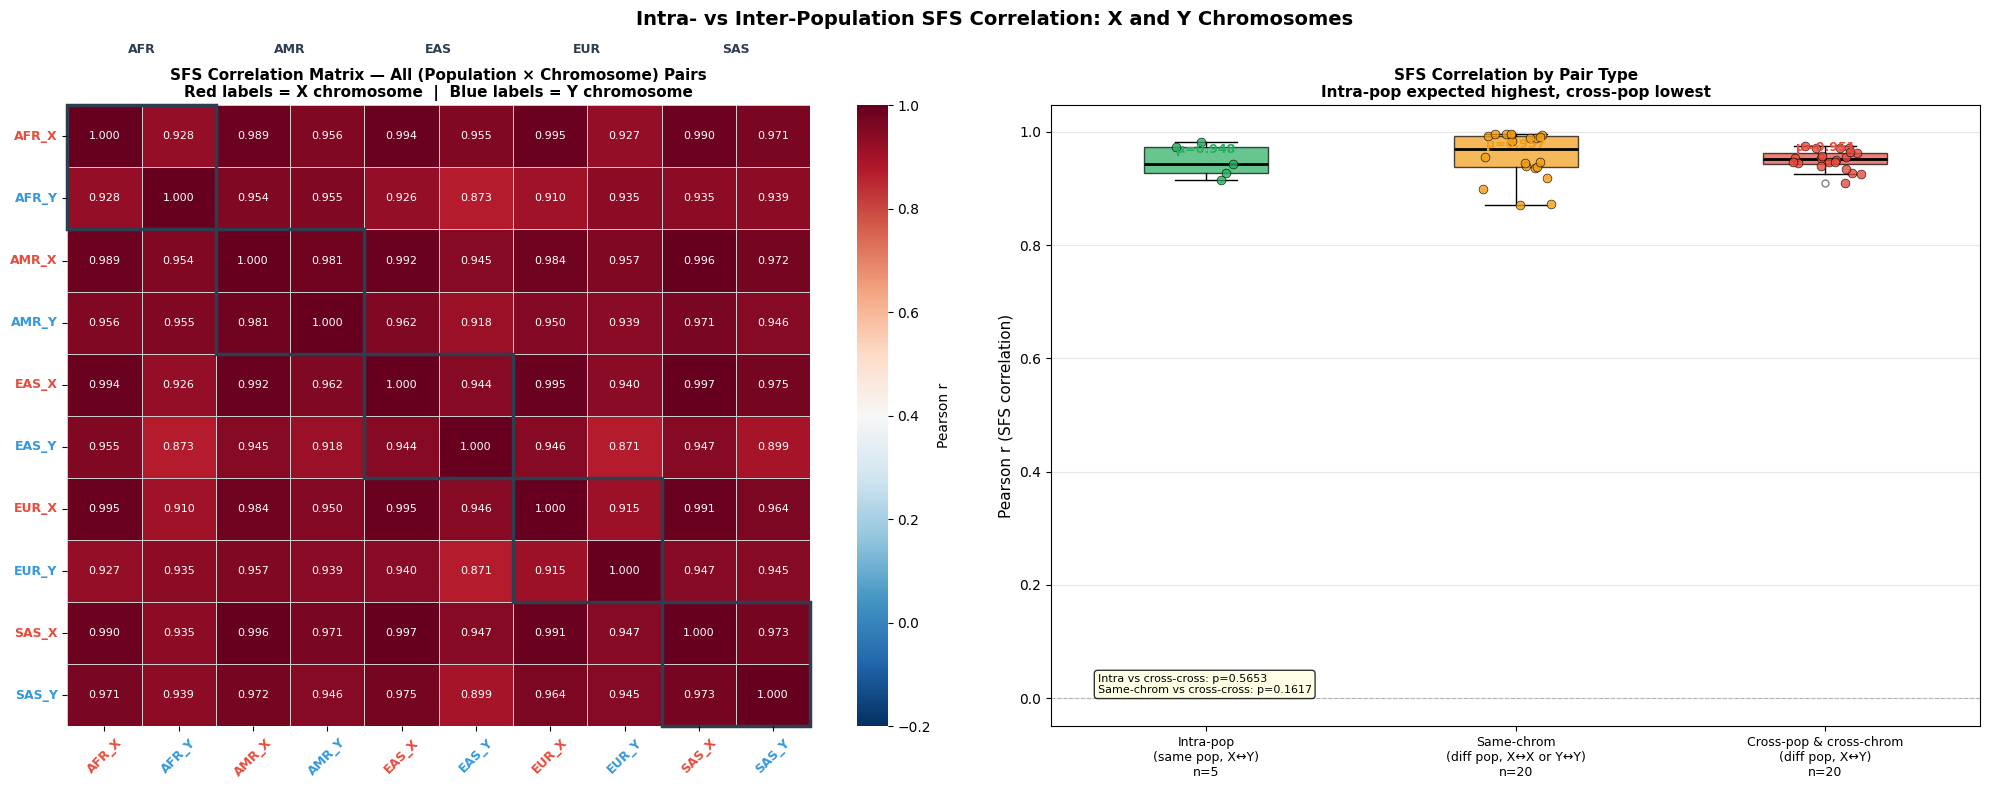

In [6]:
# ── Figure 1: Full 10×10 heatmap with block annotations ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Colour the labels by chromosome
label_colors = ['#E74C3C' if k.endswith('_X') else '#3498DB' for k in keys]

ax = axes[0]
im = sns.heatmap(
    corr_10.astype(float), annot=True, fmt='.3f', cmap='RdBu_r',
    vmin=-0.2, vmax=1.0, ax=ax, linewidths=0.5, linecolor='#CCCCCC',
    annot_kws={'size': 8}, cbar_kws={'label': 'Pearson r'}
)
ax.set_title('SFS Correlation Matrix — All (Population × Chromosome) Pairs\n'
             'Red labels = X chromosome  |  Blue labels = Y chromosome',
             fontsize=11, fontweight='bold')
# Colour tick labels
for tick, clr in zip(ax.get_xticklabels(), label_colors):
    tick.set_color(clr); tick.set_fontweight('bold')
for tick, clr in zip(ax.get_yticklabels(), label_colors):
    tick.set_color(clr); tick.set_fontweight('bold')
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0, labelsize=9)

# Draw block outlines: 2×2 blocks per population (X and Y together)
for i in range(5):
    rect = mpatches.FancyBboxPatch(
        (i*2, i*2), 2, 2,
        boxstyle='square,pad=0',
        linewidth=2.5, edgecolor='#2C3E50', facecolor='none',
        transform=ax.transData, clip_on=False
    )
    ax.add_patch(rect)
    # Label outside
    ax.text(i*2 + 1, -0.8, POP_COLS[i], ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#2C3E50')

# ── Figure 1 right: Box plots per category ───────────────────────────────────
ax2 = axes[1]
cat_data = [
    intra_pop_cross_chrom,
    same_chrom_diff_pop,
    cross_pop_cross_chrom,
]
cat_labels = [
    f'Intra-pop\n(same pop, X↔Y)\nn={len(intra_pop_cross_chrom)}',
    f'Same-chrom\n(diff pop, X↔X or Y↔Y)\nn={len(same_chrom_diff_pop)}',
    f'Cross-pop & cross-chrom\n(diff pop, X↔Y)\nn={len(cross_pop_cross_chrom)}',
]
cat_colors = ['#27AE60', '#F39C12', '#E74C3C']

bp = ax2.boxplot(cat_data, patch_artist=True, widths=0.4,
                 medianprops={'color': 'black', 'linewidth': 2})
for patch, clr in zip(bp['boxes'], cat_colors):
    patch.set_facecolor(clr); patch.set_alpha(0.7)
for flier in bp['fliers']:
    flier.set(marker='o', markersize=5, alpha=0.5)

# Overlay individual points
for i, (data, clr) in enumerate(zip(cat_data, cat_colors), start=1):
    jitter = np.random.default_rng(42).uniform(-0.12, 0.12, len(data))
    ax2.scatter(np.full(len(data), i) + jitter, data, color=clr,
                s=40, edgecolors='black', linewidth=0.5, zorder=3, alpha=0.8)
    ax2.text(i, np.mean(data) + 0.015, f'μ={np.mean(data):.3f}',
             ha='center', fontsize=9, fontweight='bold', color=clr)

ax2.set_xticks([1, 2, 3])
ax2.set_xticklabels(cat_labels, fontsize=9)
ax2.set_ylabel('Pearson r (SFS correlation)', fontsize=11)
ax2.set_title('SFS Correlation by Pair Type\n'
              'Intra-pop expected highest, cross-pop lowest',
              fontsize=11, fontweight='bold')
ax2.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax2.grid(axis='y', alpha=0.3)

# Mann-Whitney U test between categories
from scipy.stats import mannwhitneyu
stat, p_intra_vs_cross = mannwhitneyu(intra_pop_cross_chrom, cross_pop_cross_chrom, alternative='greater')
stat, p_same_vs_cross  = mannwhitneyu(same_chrom_diff_pop,   cross_pop_cross_chrom, alternative='greater')
ax2.text(0.05, 0.05,
         f'Intra vs cross-cross: p={p_intra_vs_cross:.4f}\nSame-chrom vs cross-cross: p={p_same_vs_cross:.4f}',
         transform=ax2.transAxes, fontsize=8, verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('Intra- vs Inter-Population SFS Correlation: X and Y Chromosomes',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/Users/aaditya/VS Code/1000 genome project/Output /coevo_12a_intra_inter_heatmap.png",
            dpi=150, bbox_inches='tight')
plt.show()

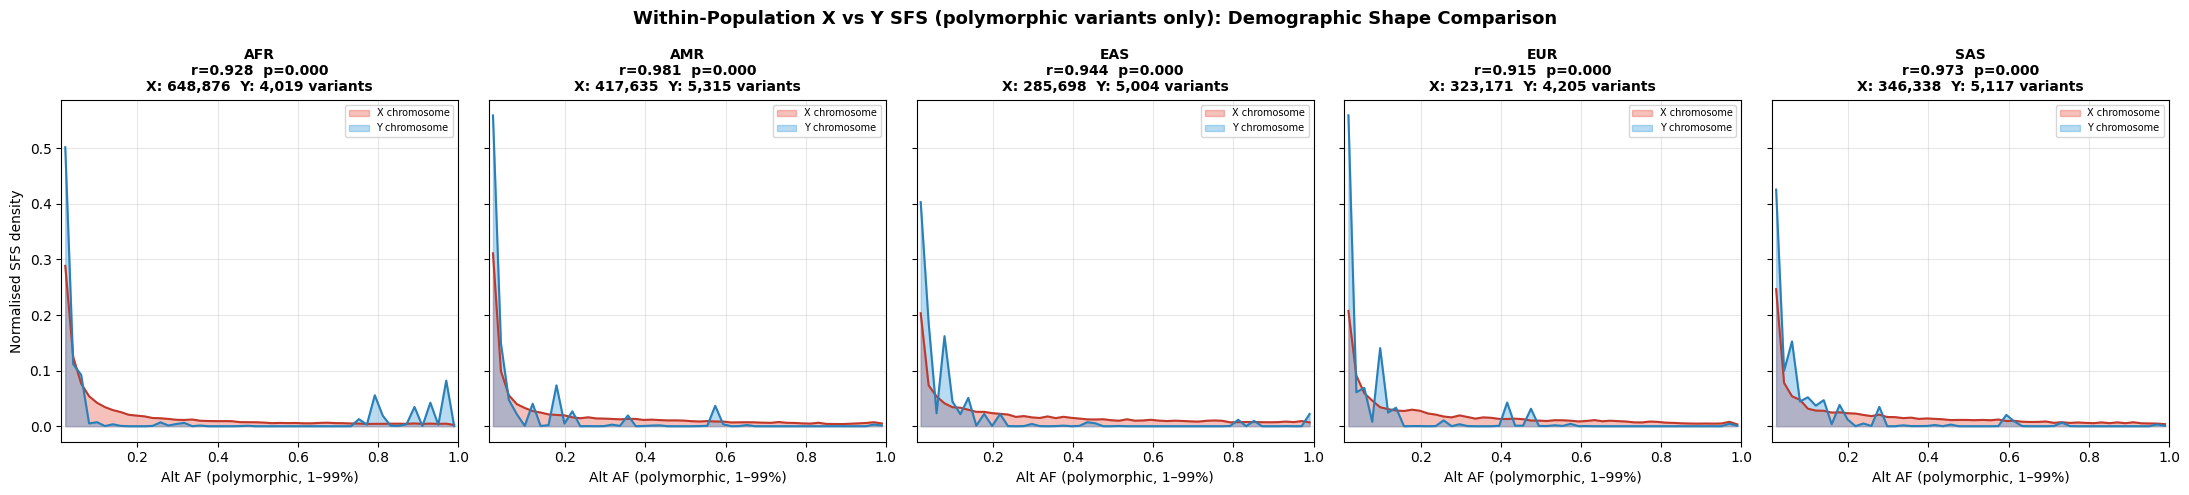

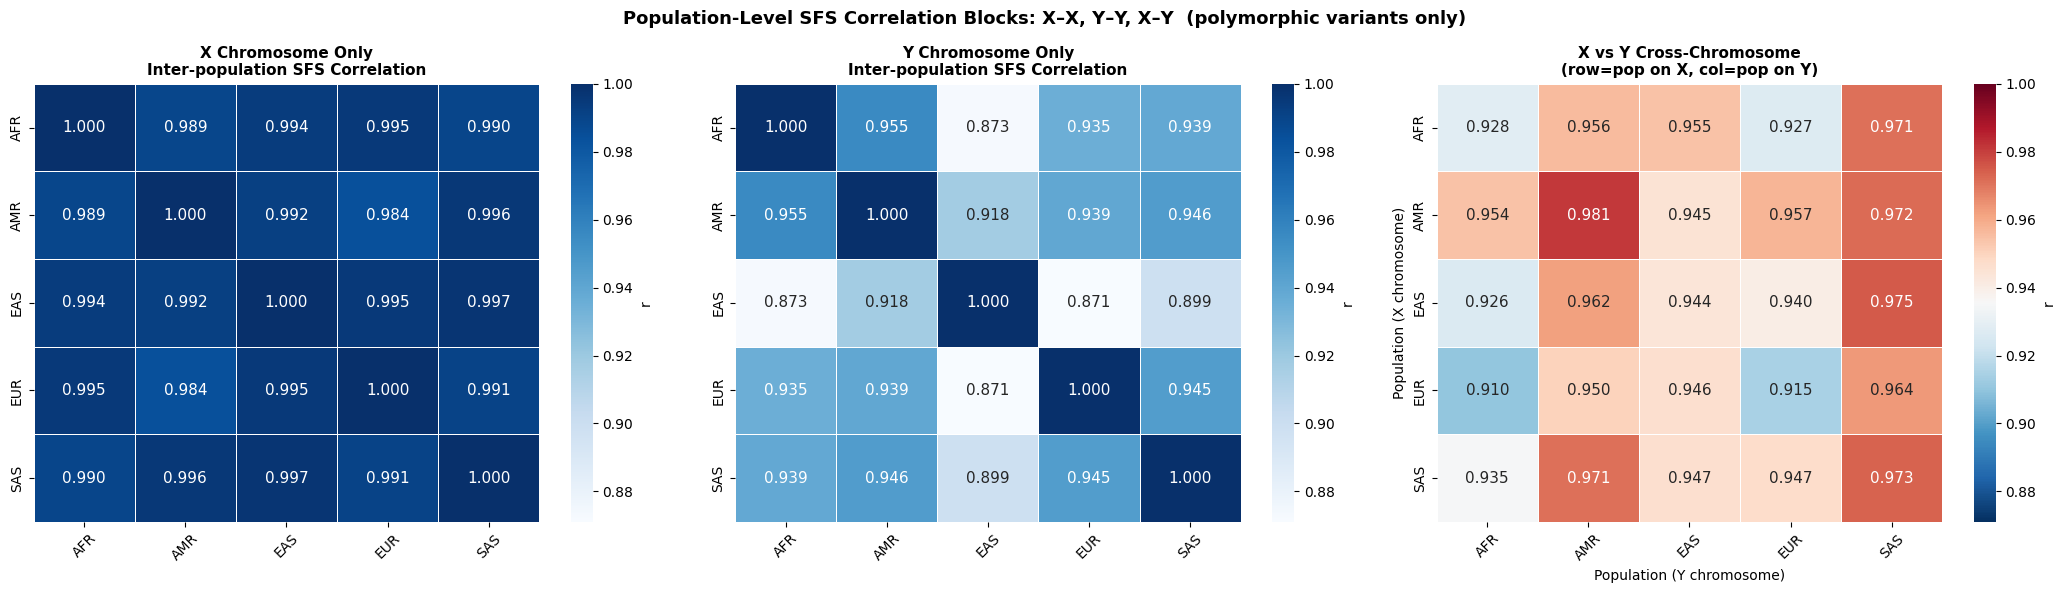


Mean correlations by block:
  X–X (diff pop)  : mean r = 0.9923
  Y–Y (diff pop)  : mean r = 0.9220
  X–Y (same pop)  : mean r = 0.9483  ← intra-pop, cross-chrom
  X–Y (diff pop)  : mean r = 0.9505  ← inter-pop, cross-chrom


In [7]:
# ── Figure 2: Within-population X vs Y SFS overlays (5 panels) ───────────────
fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)

for ax, pop in zip(axes, POP_COLS):
    xv = sfs_vectors[f'{pop}_X']
    yv = sfs_vectors[f'{pop}_Y']
    r, p = pearsonr(xv, yv)

    ax.fill_between(mid, xv, alpha=0.35, color='#E74C3C', label='X chromosome')
    ax.fill_between(mid, yv, alpha=0.35, color='#3498DB', label='Y chromosome')
    ax.plot(mid, xv, '-', color='#C0392B', linewidth=1.5)
    ax.plot(mid, yv, '-', color='#2980B9', linewidth=1.5)

    nx = sfs_counts[f'{pop}_X']
    ny = sfs_counts[f'{pop}_Y']
    ax.set_title(f'{pop}\nr={r:.3f}  p={p:.3f}\nX: {nx:,}  Y: {ny:,} variants', fontsize=10, fontweight='bold')
    ax.set_xlabel('Alt AF (polymorphic, 1–99%)')
    if ax == axes[0]:
        ax.set_ylabel('Normalised SFS density')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(alpha=0.3)
    ax.set_xlim(0.01, 1.0)

plt.suptitle('Within-Population X vs Y SFS (polymorphic variants only): Demographic Shape Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/Users/aaditya/VS Code/1000 genome project/Output /coevo_12b_within_pop_sfs.png",
            dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 3: Cross-population comparison — X-only and Y-only 5×5 blocks ─────
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

x_keys = [f'{p}_X' for p in POP_COLS]
y_keys = [f'{p}_Y' for p in POP_COLS]

corr_xx = corr_10.loc[x_keys, x_keys].astype(float)
corr_yy = corr_10.loc[y_keys, y_keys].astype(float)
corr_xy = corr_10.loc[x_keys, y_keys].astype(float)

corr_xx.index   = corr_xx.columns   = POP_COLS
corr_yy.index   = corr_yy.columns   = POP_COLS
corr_xy.index   = POP_COLS
corr_xy.columns = POP_COLS

vmin_all = min(corr_xx.values.min(), corr_yy.values.min(), corr_xy.values.min())

sns.heatmap(corr_xx, annot=True, fmt='.3f', cmap='Blues',
            vmin=vmin_all, vmax=1.0, ax=axes[0], linewidths=0.5,
            annot_kws={'size': 11}, cbar_kws={'label': 'r'})
axes[0].set_title('X Chromosome Only\nInter-population SFS Correlation',
                  fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(corr_yy, annot=True, fmt='.3f', cmap='Blues',
            vmin=vmin_all, vmax=1.0, ax=axes[1], linewidths=0.5,
            annot_kws={'size': 11}, cbar_kws={'label': 'r'})
axes[1].set_title('Y Chromosome Only\nInter-population SFS Correlation',
                  fontsize=11, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

sns.heatmap(corr_xy, annot=True, fmt='.3f', cmap='RdBu_r',
            vmin=vmin_all, vmax=1.0, ax=axes[2], linewidths=0.5,
            annot_kws={'size': 11}, cbar_kws={'label': 'r'})
axes[2].set_title('X vs Y Cross-Chromosome\n(row=pop on X, col=pop on Y)',
                  fontsize=11, fontweight='bold')
axes[2].set_xlabel('Population (Y chromosome)')
axes[2].set_ylabel('Population (X chromosome)')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('Population-Level SFS Correlation Blocks: X–X, Y–Y, X–Y  (polymorphic variants only)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/Users/aaditya/VS Code/1000 genome project/Output /coevo_12c_pop_blocks.png",
            dpi=150, bbox_inches='tight')
plt.show()

print('\nMean correlations by block:')
xx_offdiag = corr_xx.values[~np.eye(5, dtype=bool)]
yy_offdiag = corr_yy.values[~np.eye(5, dtype=bool)]
xy_diag    = np.diag(corr_xy.values)
xy_offdiag = corr_xy.values[~np.eye(5, dtype=bool)]

print(f'  X–X (diff pop)  : mean r = {xx_offdiag.mean():.4f}')
print(f'  Y–Y (diff pop)  : mean r = {yy_offdiag.mean():.4f}')
print(f'  X–Y (same pop)  : mean r = {xy_diag.mean():.4f}  ← intra-pop, cross-chrom')
print(f'  X–Y (diff pop)  : mean r = {xy_offdiag.mean():.4f}  ← inter-pop, cross-chrom')


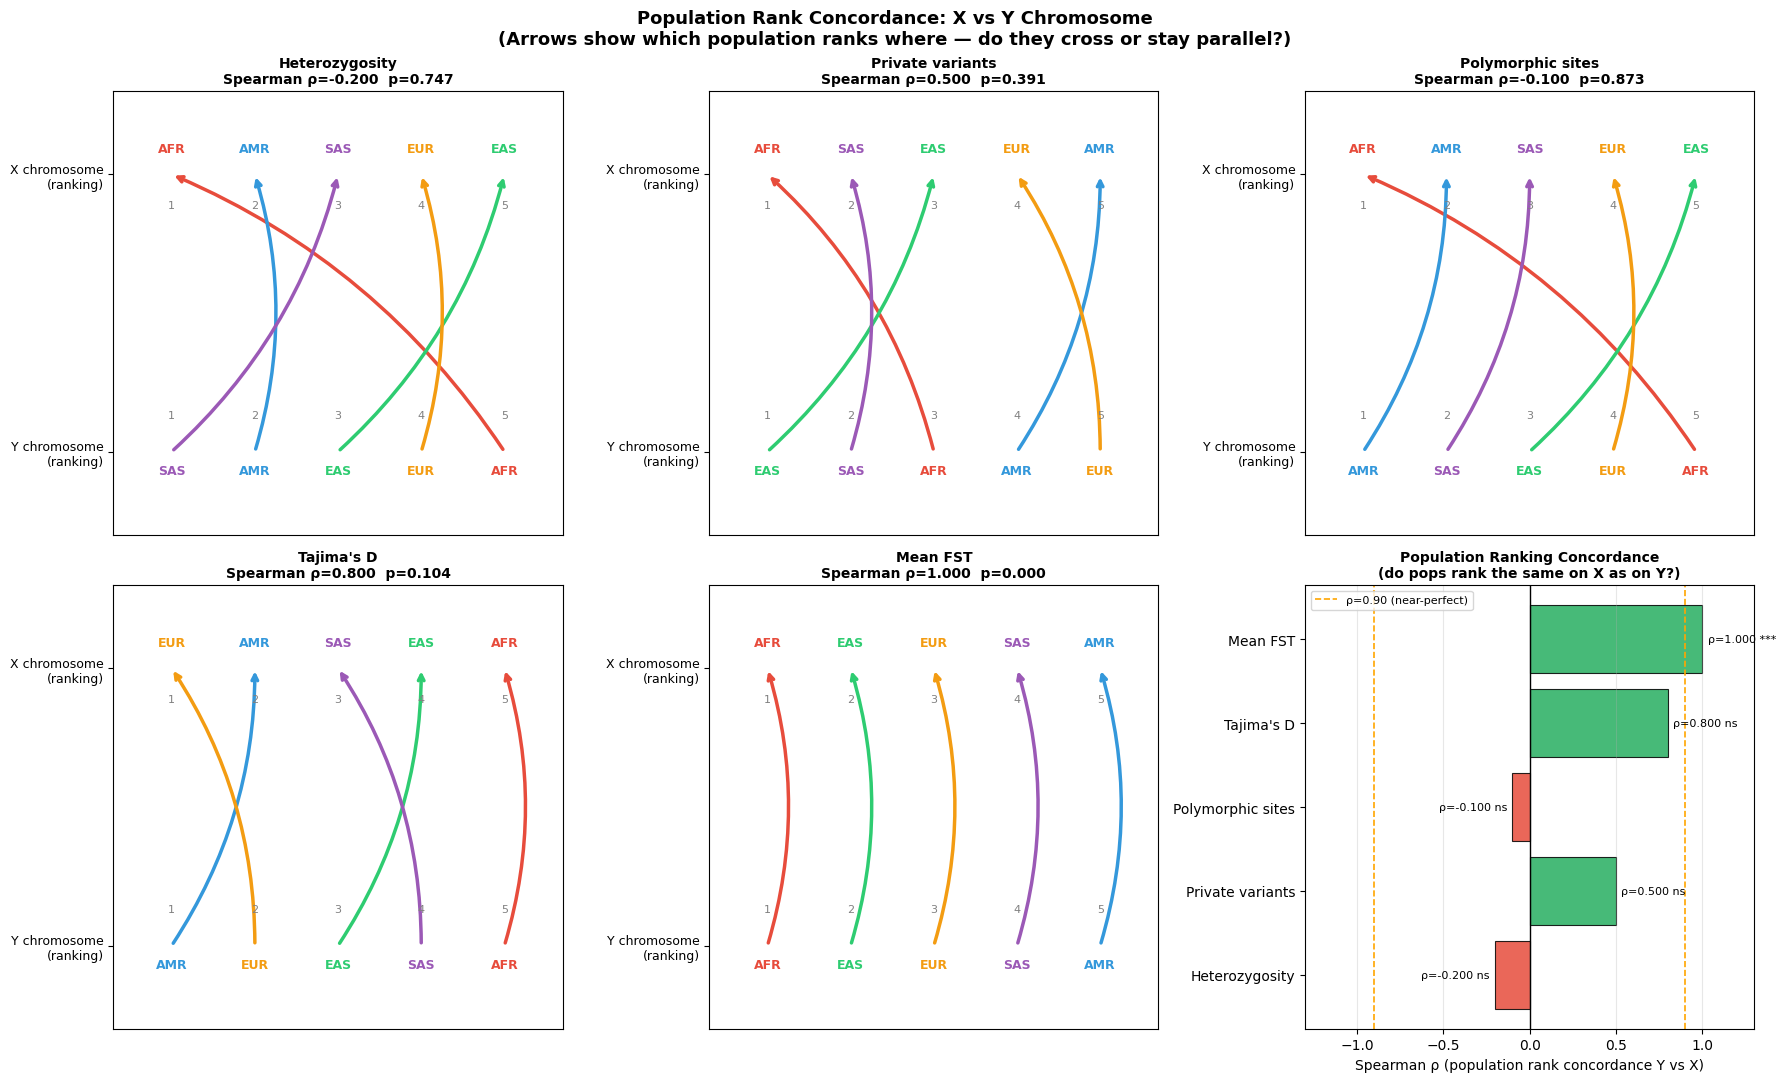


Rank concordance summary:
           metric  spearman_rho      p
   Heterozygosity          -0.2 0.7471
 Private variants           0.5 0.3910
Polymorphic sites          -0.1 0.8729
       Tajima's D           0.8 0.1041
         Mean FST           1.0 0.0000


In [8]:
# ── Figure 4: Rank concordance — do populations rank the same on X and Y? ────
# For 6 diversity metrics, rank the 5 pops on X and on Y, then check if the rankings agree

rank_metrics = {
    'Heterozygosity' : (y_div['avg_heterozygosity'].astype(float).values,
                        x_div['avg_heterozygosity'].astype(float).values),
    'Private variants': (y_div['private_variants'].astype(float).values,
                         x_div['private_variants'].astype(float).values),
    'Polymorphic sites': (y_div['n_polymorphic'].astype(float).values,
                          x_div['n_polymorphic'].astype(float).values),
    "Tajima's D"      : (td_df['Y_tajD'].values,
                         td_df['X_tajD'].values),
    'Mean FST'        : (y_mfst_arr, x_mfst_arr),
}

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes_flat = axes.flatten()

rank_results = []
for idx, (metric_name, (y_vals, x_vals)) in enumerate(rank_metrics.items()):
    ax = axes_flat[idx]
    rho, p_rho = spearmanr(y_vals, x_vals)
    rank_results.append({'metric': metric_name, 'spearman_rho': rho, 'p': p_rho})

    # Rank 1 = highest
    y_rank = pd.Series(y_vals, index=POP_COLS).rank(ascending=False).astype(int)
    x_rank = pd.Series(x_vals, index=POP_COLS).rank(ascending=False).astype(int)

    for pop in POP_COLS:
        ax.annotate('', xy=(x_rank[pop], 1), xytext=(y_rank[pop], 0),
                    arrowprops=dict(arrowstyle='->', color=POP_COLORS[pop],
                                   lw=2.5, connectionstyle='arc3,rad=0.15'))
        ax.text(y_rank[pop], -0.08, pop, ha='center', fontsize=9,
                fontweight='bold', color=POP_COLORS[pop])
        ax.text(x_rank[pop],  1.08, pop, ha='center', fontsize=9,
                fontweight='bold', color=POP_COLORS[pop])

    ax.set_xlim(0.3, 5.7)
    ax.set_ylim(-0.3, 1.3)
    ax.set_xticks([]); ax.set_yticks([0, 1])
    ax.set_yticklabels(['Y chromosome\n(ranking)', 'X chromosome\n(ranking)'], fontsize=9)
    ax.set_title(f'{metric_name}\nSpearman ρ={rho:.3f}  p={p_rho:.3f}',
                 fontsize=10, fontweight='bold')
    ax.grid(axis='x', alpha=0.2)

    # Add rank numbers on arrows
    for pop in POP_COLS:
        ax.text(y_rank[pop], 0.12, str(y_rank[pop]), ha='center', fontsize=8, color='gray')
        ax.text(x_rank[pop], 0.88, str(x_rank[pop]), ha='center', fontsize=8, color='gray')

# Summary panel
ax_sum = axes_flat[5]
rr_df = pd.DataFrame(rank_results)
bar_colors = ['#27AE60' if r > 0 else '#E74C3C' for r in rr_df['spearman_rho']]
bars = ax_sum.barh(rr_df['metric'], rr_df['spearman_rho'], color=bar_colors,
                   alpha=0.85, edgecolor='black', linewidth=0.8)
ax_sum.axvline(0, color='black', linewidth=1)
ax_sum.axvline(0.9, color='orange', linewidth=1.2, linestyle='--', label='ρ=0.90 (near-perfect)')
ax_sum.axvline(-0.9, color='orange', linewidth=1.2, linestyle='--')
for bar, row in zip(bars, rr_df.itertuples()):
    rho_val = row.spearman_rho
    sig = '***' if row.p < 0.01 else ('**' if row.p < 0.05 else ('*' if row.p < 0.10 else 'ns'))
    ax_sum.text(rho_val + (0.03 if rho_val >= 0 else -0.03), bar.get_y() + bar.get_height()/2,
                f'ρ={rho_val:.3f} {sig}', va='center', ha='left' if rho_val >= 0 else 'right', fontsize=8)
ax_sum.set_xlabel('Spearman ρ (population rank concordance Y vs X)')
ax_sum.set_title('Population Ranking Concordance\n(do pops rank the same on X as on Y?)',
                 fontsize=10, fontweight='bold')
ax_sum.legend(fontsize=8)
ax_sum.set_xlim(-1.3, 1.3)
ax_sum.grid(axis='x', alpha=0.3)

plt.suptitle('Population Rank Concordance: X vs Y Chromosome\n'
             '(Arrows show which population ranks where — do they cross or stay parallel?)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/Users/aaditya/VS Code/1000 genome project/Output /coevo_12d_rank_concordance.png",
            dpi=150, bbox_inches='tight')
plt.show()

print('\nRank concordance summary:')
print(rr_df.round(4).to_string(index=False))

In [9]:
# ── Full ranked table of all 45 unique pairs ──────────────────────────────────
all_pairs = []
for k1 in keys:
    for k2 in keys:
        if k1 >= k2:
            continue
        p1, c1 = k1.rsplit('_', 1)
        p2, c2 = k2.rsplit('_', 1)
        r = float(corr_10.loc[k1, k2])
        if p1 == p2 and c1 == c2:
            category = 'Identical'
        elif p1 == p2 and c1 != c2:
            category = 'Same-pop / cross-chrom'
        elif p1 != p2 and c1 == c2:
            category = 'Diff-pop / same-chrom'
        else:
            category = 'Diff-pop / cross-chrom'
        all_pairs.append({'pair': f'{k1}  ↔  {k2}', 'r': r, 'category': category,
                          'pop_same': p1 == p2, 'chrom_same': c1 == c2})

pairs_df = pd.DataFrame(all_pairs).sort_values('r', ascending=False)

print('All 45 pairwise SFS correlations (sorted highest → lowest):')
print(f'{"Pair":<35} {"r":>8}  Category')
print('-' * 80)
for _, row in pairs_df.iterrows():
    print(f'{row["pair"]:<35} {row["r"]:>8.4f}  {row["category"]}')

print('\n── Summary statistics by category ──')
print(pairs_df.groupby('category')['r'].agg(['mean','std','min','max']).round(4))

All 45 pairwise SFS correlations (sorted highest → lowest):
Pair                                       r  Category
--------------------------------------------------------------------------------
EAS_X  ↔  SAS_X                       0.9970  Diff-pop / same-chrom
AMR_X  ↔  SAS_X                       0.9957  Diff-pop / same-chrom
EAS_X  ↔  EUR_X                       0.9953  Diff-pop / same-chrom
AFR_X  ↔  EUR_X                       0.9951  Diff-pop / same-chrom
AFR_X  ↔  EAS_X                       0.9938  Diff-pop / same-chrom
AMR_X  ↔  EAS_X                       0.9921  Diff-pop / same-chrom
EUR_X  ↔  SAS_X                       0.9908  Diff-pop / same-chrom
AFR_X  ↔  SAS_X                       0.9898  Diff-pop / same-chrom
AFR_X  ↔  AMR_X                       0.9890  Diff-pop / same-chrom
AMR_X  ↔  EUR_X                       0.9842  Diff-pop / same-chrom
AMR_X  ↔  AMR_Y                       0.9813  Same-pop / cross-chrom
EAS_X  ↔  SAS_Y                       0.9750  Diff-pop 